# 1. Import Requirements


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import Callback
import tensorflow as tf
import pickle



# 2. Load & Preprocess Data


In [2]:
DATASET_PATH = '../data/dataset_landmarks.csv'
sequences = []
labels = []
TIME_STEPS = 40

print("Loading dataset from", DATASET_PATH)
df = pd.read_csv(DATASET_PATH)

for (label, seq_id), group in df.groupby(['label', 'sequence']):
    if len(group) == TIME_STEPS: 
        # Feature columns start at index 4 (rh_x_0, etc.)
        sequences.append(group.iloc[:, 4:].values) 
        labels.append(label)

X = np.array(sequences)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

if X.shape[0] == 0:
    raise ValueError("No sequences found! Please check TIME_STEPS and your dataset groupings.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_res = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
X_train, X_test = X_train_res, X_test_res



Loading dataset from ../data/dataset_landmarks.csv
X shape: (229, 40, 63)
y shape: (229,)


# 2.5 Exploratory Data Analysis (EDA)
Exploring sequence distribution and verifying dataset integrity before training.

--- Raw Dataset Stats ---
Total rows in raw dataset: 9160
Unique labels: ['buka_kunci' 'kunci']
Total unique sequences: 134

--- Sequences per Label ---


,label,sequence
0,buka_kunci,123
1,kunci,106


C:\Users\ikhwa\AppData\Local\Temp\ipykernel_12640\3921553039.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='sequence', data=seq_counts, palette='viridis')


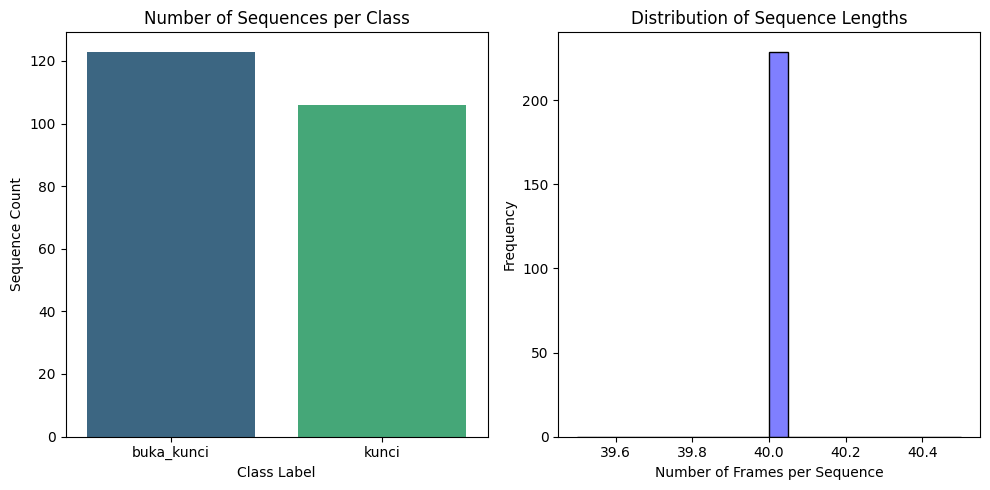


--- Valid Sequence Stats (Ready for Training) ---
Total valid sequences (exactly 40 frames): 229
Valid sequences per class: {np.str_('buka_kunci'): np.int64(123), np.str_('kunci'): np.int64(106)}


In [3]:
print("--- Raw Dataset Stats ---")
print(f"Total rows in raw dataset: {len(df)}")
print(f"Unique labels: {df['label'].unique()}")
print(f"Total unique sequences: {df['sequence'].nunique()}")

# Calculate sequences per label based on sequence identifiers
seq_counts = df.groupby('label')['sequence'].nunique().reset_index()
print("\n--- Sequences per Label ---")
display(seq_counts)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='label', y='sequence', data=seq_counts, palette='viridis')
plt.title('Number of Sequences per Class')
plt.xlabel('Class Label')
plt.ylabel('Sequence Count')

seq_lengths = df.groupby(['label', 'sequence']).size().reset_index(name='length')
plt.subplot(1, 2, 2)
sns.histplot(seq_lengths['length'], bins=20, kde=True, color='blue')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Number of Frames per Sequence')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n--- Valid Sequence Stats (Ready for Training) ---")
print(f"Total valid sequences (exactly {TIME_STEPS} frames): {X.shape[0]}")
unique, counts = np.unique(y, return_counts=True)
valid_counts = dict(zip(unique, counts))
print("Valid sequences per class:", valid_counts)


# 3. Custom Sklearn Metric Callback
This callback injects Scikit-Learn metrics at the end of every epoch so we can plot them alongside Keras Accuracy!


In [16]:
class SklearnMetricsCallback(Callback):
    def __init__(self, X_train, y_train, X_val, y_val):
        super().__init__()
        self.X_t = X_train
        self.y_t = np.argmax(y_train, axis=1)
        self.X_v = X_val
        self.y_v = np.argmax(y_val, axis=1)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        
        # Validation Metrics
        val_pred = np.argmax(self.model.predict(self.X_v, verbose=0), axis=1)
        logs['val_prec'] = precision_score(self.y_v, val_pred, average='macro', zero_division=0)
        logs['val_recall'] = recall_score(self.y_v, val_pred, average='macro', zero_division=0)
        logs['val_f1'] = f1_score(self.y_v, val_pred, average='macro', zero_division=0)
        
        # Train Metrics
        train_pred = np.argmax(self.model.predict(self.X_t, verbose=0), axis=1)
        logs['train_prec'] = precision_score(self.y_t, train_pred, average='macro', zero_division=0)
        logs['train_recall'] = recall_score(self.y_t, train_pred, average='macro', zero_division=0)
        logs['train_f1'] = f1_score(self.y_t, train_pred, average='macro', zero_division=0)



# 4. Grid Search Training (Base, Deep, Wide) x (Adam, SGD)


In [17]:
DROPOUT_RATE = 0.2
EPOCHS = 20
BATCH_SIZE = 16

configs = [
    {'name': 'Base_Adam',       'layers': [64],     'dense': 32, 'opt': 'adam'},
    {'name': 'Base_SGD',        'layers': [64],     'dense': 32, 'opt': 'sgd'},
    {'name': 'DeepLSTM_Adam',   'layers': [64, 32], 'dense': 32, 'opt': 'adam'},
    {'name': 'DeepLSTM_SGD',    'layers': [64, 32], 'dense': 32, 'opt': 'sgd'},
    {'name': 'Wide_Adam',       'layers': [128],    'dense': 64, 'opt': 'adam'},
    {'name': 'Wide_SGD',        'layers': [128],    'dense': 64, 'opt': 'sgd'}
]

histories = {}
best_f1_score = 0
best_model = None
best_name = ""
best_acc = 0

for conf in configs:
    print(f"\n=== Training {conf['name']} ===")
    model = Sequential()
    
    if len(conf['layers']) > 1:
        model.add(LSTM(conf['layers'][0], return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(DROPOUT_RATE))
        model.add(LSTM(conf['layers'][1], return_sequences=False))
    else:
        model.add(LSTM(conf['layers'][0], return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
        
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(conf['dense'], activation='relu'))
    model.add(Dense(y_categorical.shape[1], activation='softmax'))
    
    model.compile(optimizer=conf['opt'], loss='categorical_crossentropy', metrics=['accuracy'])
    
    metrics_cb = SklearnMetricsCallback(X_train, y_train, X_test, y_test)
    
    # Train
    history = model.fit(
        X_train, y_train, 
        epochs=EPOCHS, 
        batch_size=BATCH_SIZE, 
        validation_data=(X_test, y_test), 
        callbacks=[metrics_cb],
        verbose=1 # Show progress
    )
    
    histories[conf['name']] = history.history
    
    # Track the best model focusing strongly on F1 SCORE rather than pure accuracy
    val_f1 = history.history.get('val_f1', [0])[-1]
    val_acc_latest = history.history.get('val_accuracy', [0])[-1]
    
    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        best_acc = val_acc_latest
        best_model = model
        best_name = conf['name']

print(f"\n=== Best Model Found ===")
print(f"Name: {best_name} | Best Val F1 Score: {best_f1_score:.4f} | Acc: {best_acc:.4f}")




=== Training Base_Adam ===
Epoch 1/20


c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7705 - loss: 0.5191 - val_accuracy: 0.9565 - val_loss: 0.2911 - val_prec: 0.9562 - val_recall: 0.9562 - val_f1: 0.9562 - train_prec: 0.9447 - train_recall: 0.9459 - train_f1: 0.9452
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9290 - loss: 0.2254 - val_accuracy: 0.9783 - val_loss: 0.1401 - val_prec: 0.9773 - val_recall: 0.9800 - val_f1: 0.9782 - train_prec: 0.9885 - train_recall: 0.9898 - train_f1: 0.9890
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9945 - loss: 0.0910 - val_accuracy: 1.0000 - val_loss: 0.0438 - val_prec: 1.0000 - val_recall: 1.0000 - val_f1: 1.0000 - train_prec: 1.0000 - train_recall: 1.0000 - train_f1: 1.0000
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 0.0164 - val_prec: 1.0000 - val_recall: 1.0000 - val_f1: 1.0000 - train_prec: 1.0000 - train_recall: 1.0000 - train_f1: 1.0000
Epoch 5/20
12/12 ━━━━━━

c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6011 - loss: 0.6643 - val_accuracy: 0.8913 - val_loss: 0.5360 - val_prec: 0.9038 - val_recall: 0.9000 - val_f1: 0.8913 - train_prec: 0.8542 - train_recall: 0.8214 - train_f1: 0.8059
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7923 - loss: 0.5259 - val_accuracy: 0.9348 - val_loss: 0.4457 - val_prec: 0.9337 - val_recall: 0.9362 - val_f1: 0.9345 - train_prec: 0.9461 - train_recall: 0.9482 - train_f1: 0.9453
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9071 - loss: 0.4530 - val_accuracy: 0.9348 - val_loss: 0.3786 - val_prec: 0.9337 - val_recall: 0.9362 - val_f1: 0.9345 - train_prec: 0.9401 - train_recall: 0.9423 - train_f1: 0.9398
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9344 - loss: 0.3809 - val_accuracy: 0.9348 - val_loss: 0.3325 - val_prec: 0.9337 - val_recall: 0.9362 - val_f1: 0.9345 - train_prec: 0.9561 - train_recall: 0.9584 - train_f1: 0.9562
Epoch 5/20
12/12 ━━━━━━

...

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5082 - loss: 0.6981 - val_accuracy: 0.5870 - val_loss: 0.6626 - val_prec: 0.5813 - val_recall: 0.5781 - val_f1: 0.5772 - train_prec: 0.6475 - train_recall: 0.6348 - train_f1: 0.6321
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6885 - loss: 0.6482 - val_accuracy: 0.8696 - val_loss: 0.6108 - val_prec: 0.8844 - val_recall: 0.8610 - val_f1: 0.8655 - train_prec: 0.8270 - train_recall: 0.8137 - train_f1: 0.8160
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8197 - loss: 0.6023 - val_accuracy: 0.9130 - val_loss: 0.5647 - val_prec: 0.9181 - val_recall: 0.9086 - val_f1: 0.9115 - train_prec: 0.8842 - train_recall: 0.8686 - train_f1: 0.8717
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8525 - loss: 0.5646 - val_accuracy: 0.9130 - val_loss: 0.5191 - val_prec: 0.9181 - val_recall: 0.9086 - val_f1: 0.9115 - train_prec: 0.9108 - train_recall: 0.9039 - train_f1: 0.9060
Epoch 5/20
12/12 ━━━━━━

c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8689 - loss: 0.3721 - val_accuracy: 0.9130 - val_loss: 0.2069 - val_prec: 0.9124 - val_recall: 0.9124 - val_f1: 0.9124 - train_prec: 0.9410 - train_recall: 0.9384 - train_f1: 0.9394
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9617 - loss: 0.1045 - val_accuracy: 0.9783 - val_loss: 0.1045 - val_prec: 0.9773 - val_recall: 0.9800 - val_f1: 0.9782 - train_prec: 0.9722 - train_recall: 0.9745 - train_f1: 0.9726
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9781 - loss: 0.0439 - val_accuracy: 1.0000 - val_loss: 0.0292 - val_prec: 1.0000 - val_recall: 1.0000 - val_f1: 1.0000 - train_prec: 0.9949 - train_recall: 0.9941 - train_f1: 0.9945
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9891 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 0.0103 - val_prec: 1.0000 - val_recall: 1.0000 - val_f1: 1.0000 - train_prec: 1.0000 - train_recall: 1.0000 - train_f1: 1.0000
Epoch 5/20
12/12 ━━━━━━

c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7049 - loss: 0.6110 - val_accuracy: 0.8913 - val_loss: 0.4782 - val_prec: 0.9008 - val_recall: 0.8848 - val_f1: 0.8887 - train_prec: 0.9042 - train_recall: 0.8914 - train_f1: 0.8944
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8907 - loss: 0.4486 - val_accuracy: 0.9130 - val_loss: 0.3818 - val_prec: 0.9181 - val_recall: 0.9086 - val_f1: 0.9115 - train_prec: 0.9250 - train_recall: 0.9215 - train_f1: 0.9228
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8962 - loss: 0.3704 - val_accuracy: 0.9348 - val_loss: 0.3197 - val_prec: 0.9365 - val_recall: 0.9324 - val_f1: 0.9340 - train_prec: 0.9503 - train_recall: 0.9510 - train_f1: 0.9506
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9235 - loss: 0.3163 - val_accuracy: 0.9348 - val_loss: 0.2740 - val_prec: 0.9365 - val_recall: 0.9324 - val_f1: 0.9340 - train_prec: 0.9666 - train_recall: 0.9686 - train_f1: 0.9671
Epoch 5/20
12/12 ━━━━━━

# 5. Tabular Comparison Summary


In [19]:
summary_data = []

for name, hist in histories.items():
    summary_data.append({
        'Model Arch & Opt': name,
        'Val F1-Score': hist['val_f1'][-1],
        'Val Accuracy': hist['val_accuracy'][-1],
        'Val Precision': hist['val_prec'][-1],
        'Val Recall': hist['val_recall'][-1],
        'Train F1-Score': hist['train_f1'][-1],
        'Train Accuracy': hist['accuracy'][-1]
    })

df_summary = pd.DataFrame(summary_data)
# Sort by F1 Score descending
df_summary = df_summary.sort_values('Val F1-Score', ascending=False).reset_index(drop=True)

print("\nModel Performance Summary:")
display(df_summary.style.background_gradient(cmap='Blues'))




Model Performance Summary:


,Model Arch & Opt,Val F1-Score,Val Accuracy,Val Precision,Val Recall,Train F1-Score,Train Accuracy
0,Base_Adam,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,DeepLSTM_Adam,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Wide_Adam,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,DeepLSTM_SGD,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Base_SGD,0.978168,0.978261,0.977273,0.980000,1.000000,1.000000
5,Wide_SGD,0.978168,0.978261,0.977273,0.980000,1.000000,0.994536


# 6. Evaluate & Plot


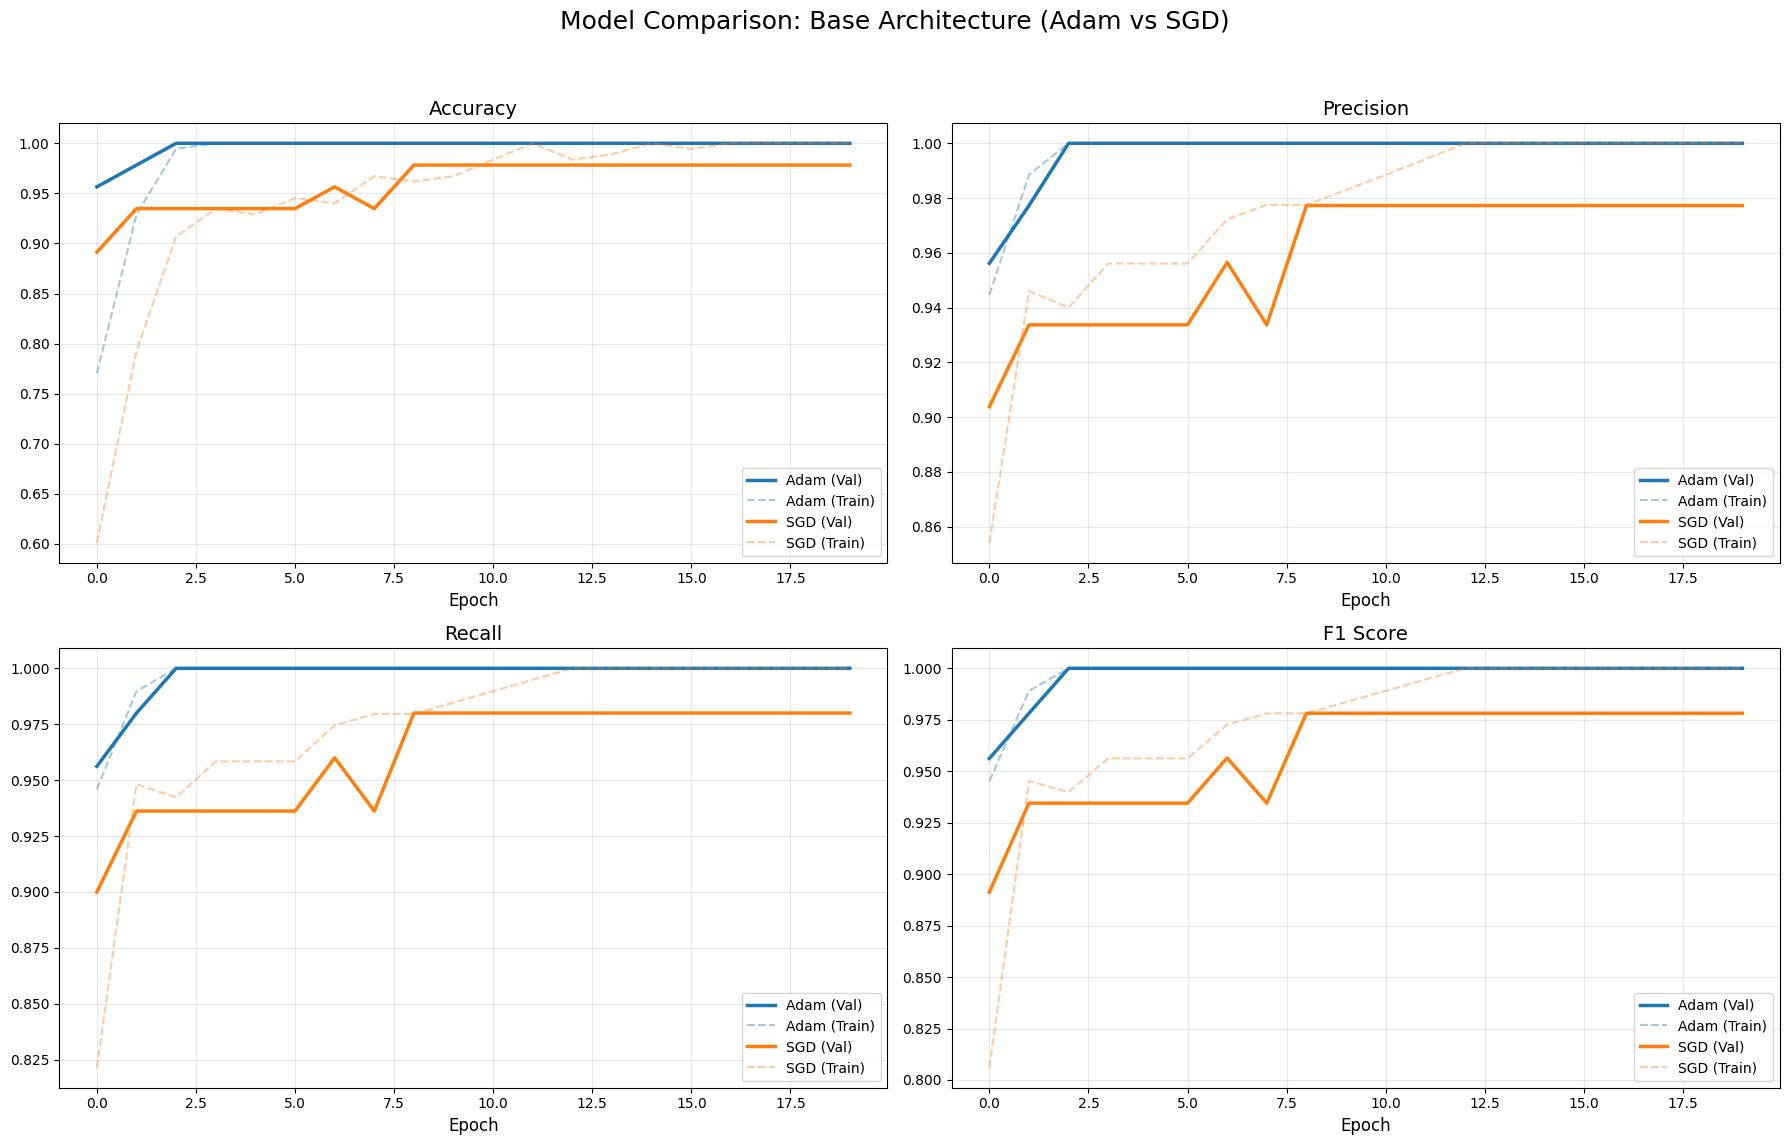

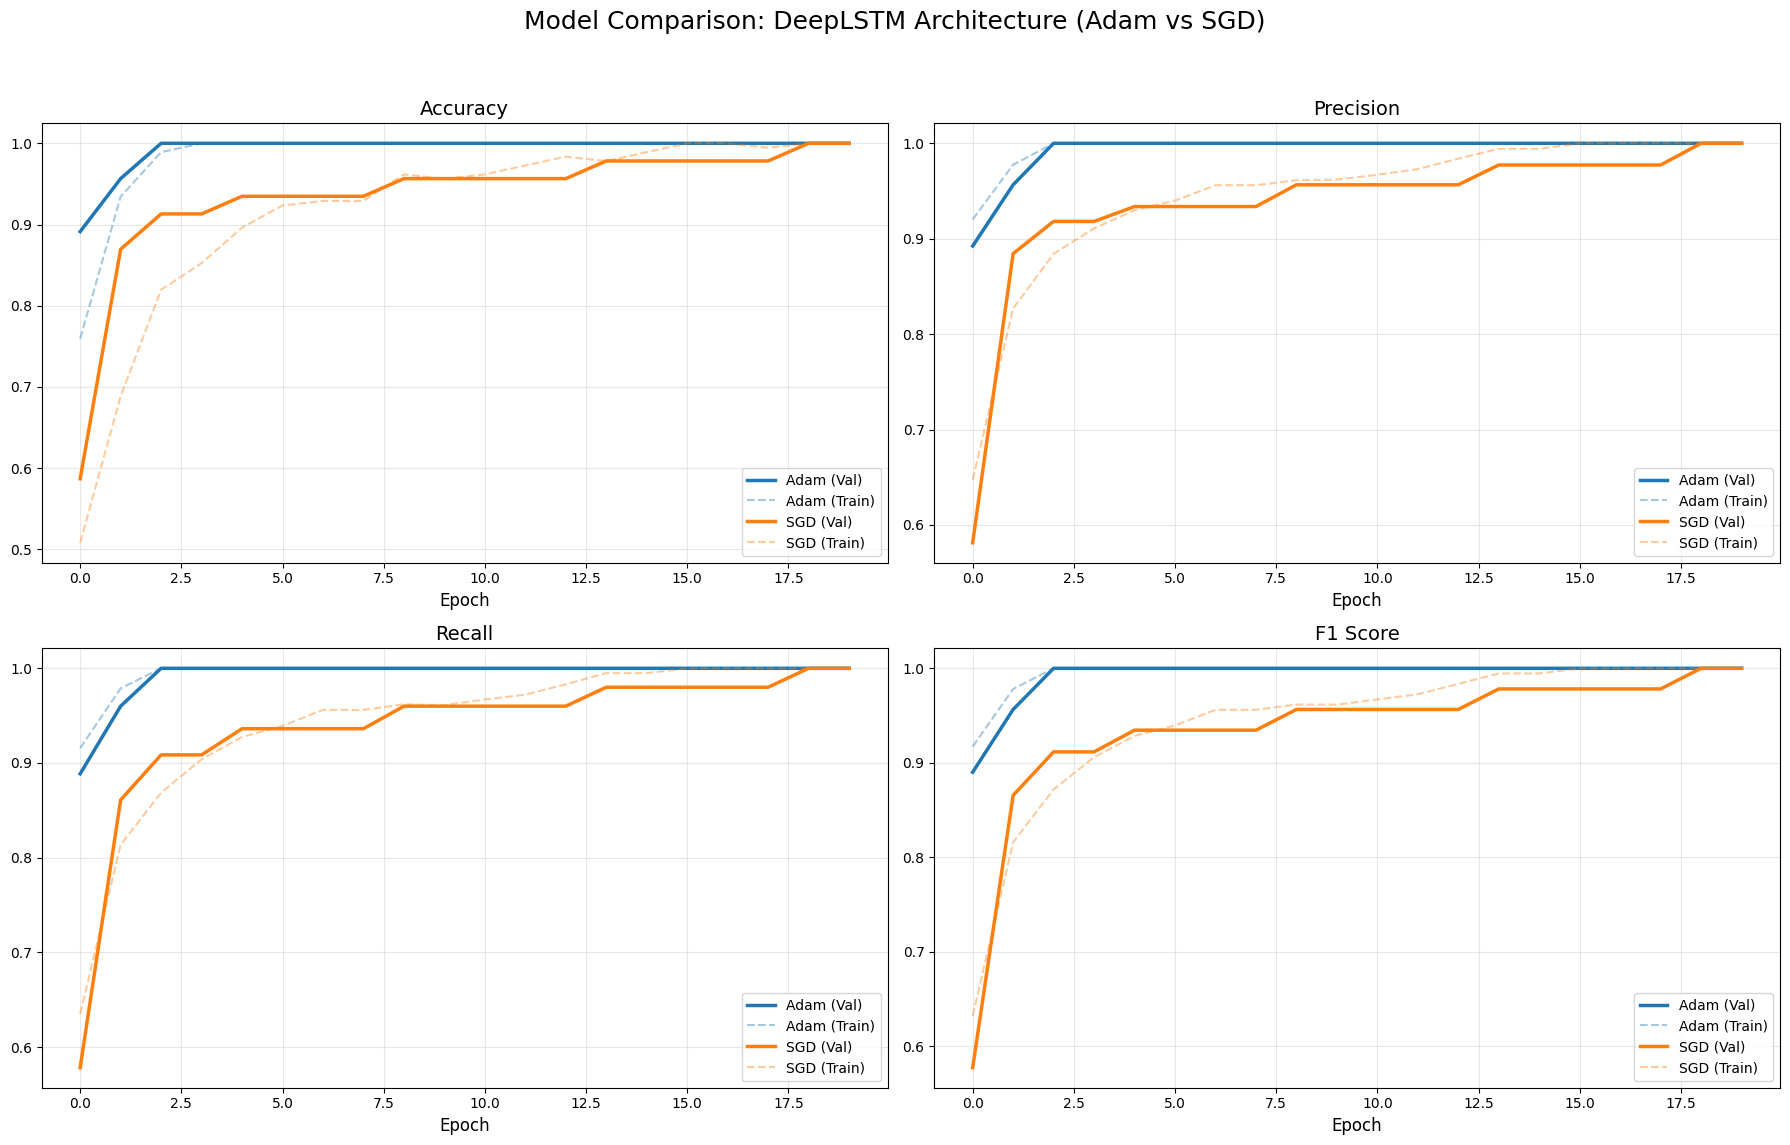

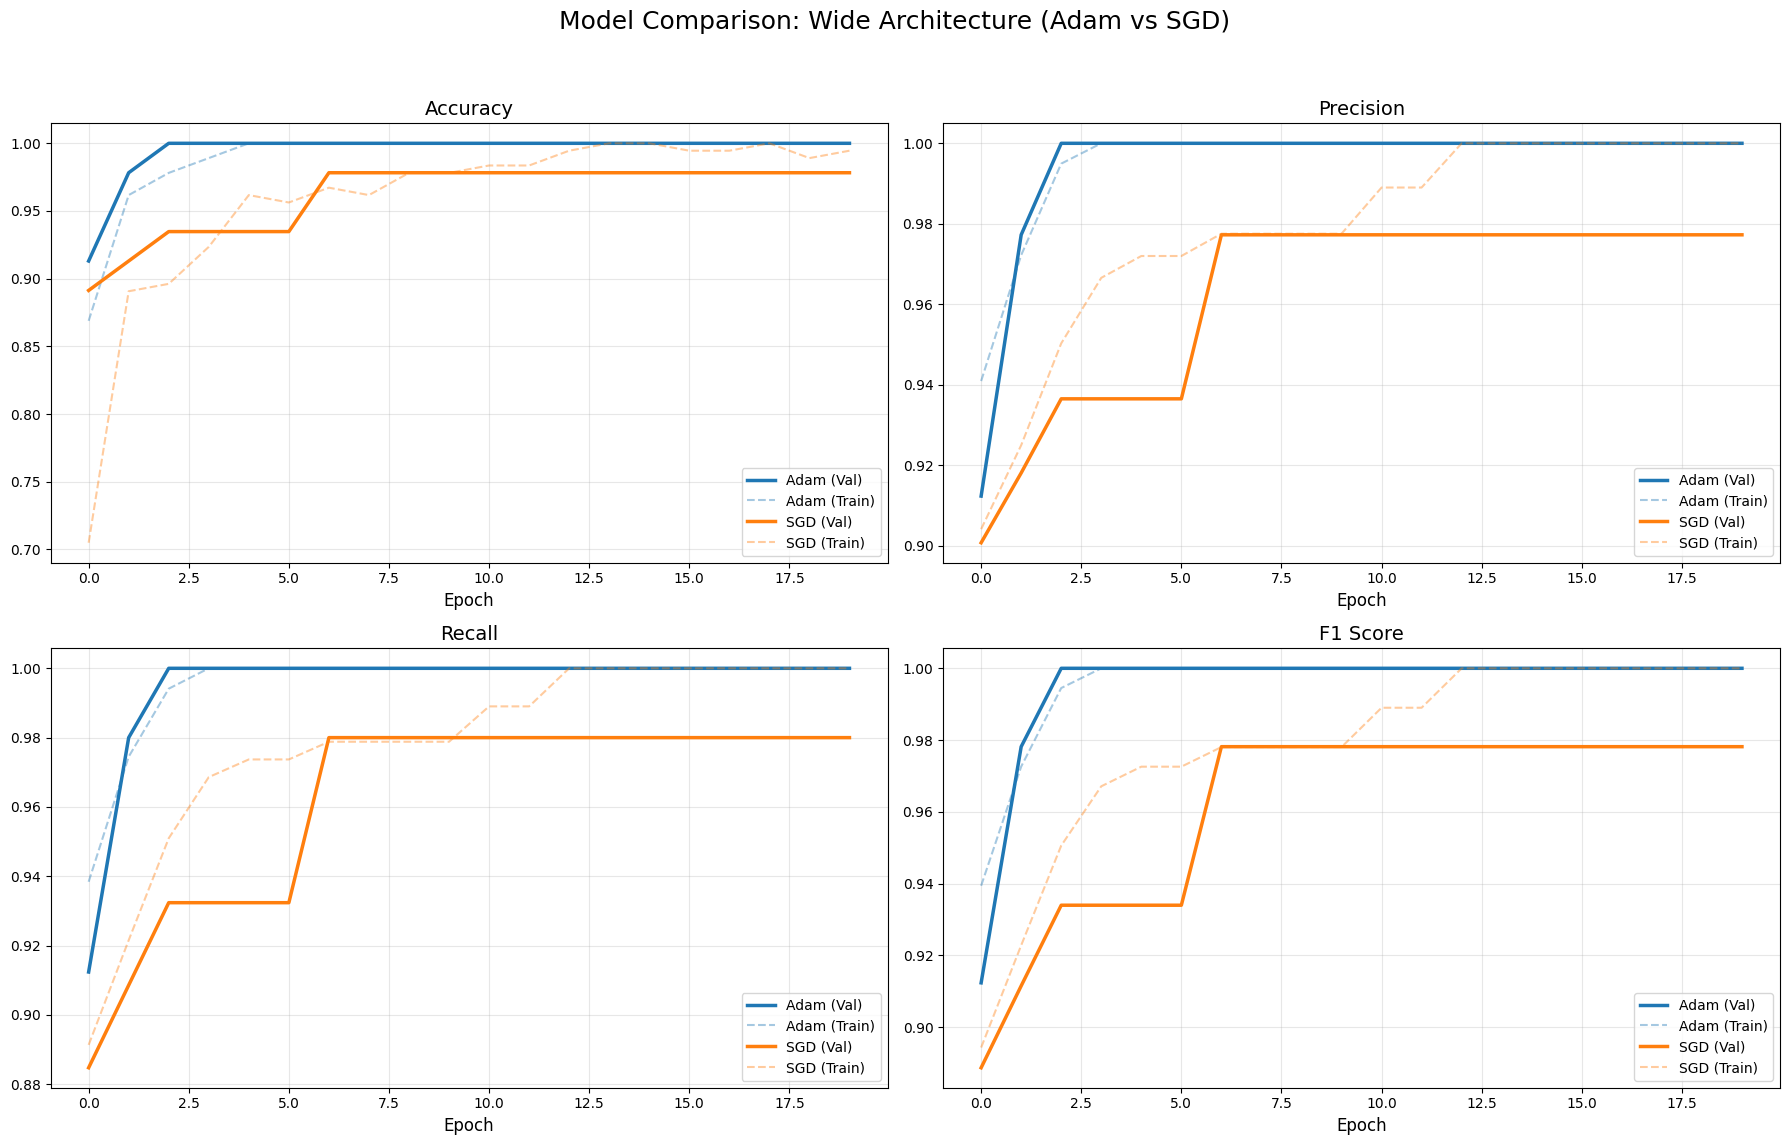


--- Final Classification Report for Base_Adam ---
              precision    recall  f1-score   support

  buka_kunci       1.00      1.00      1.00        25
       kunci       1.00      1.00      1.00        21

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



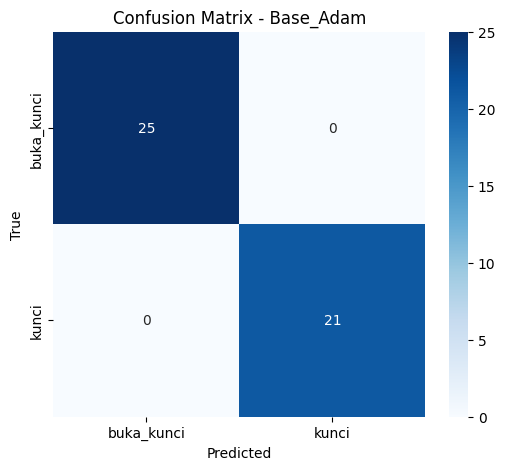

In [21]:
metrics = [
    ('Accuracy', 'accuracy', 'val_accuracy'),
    ('Precision', 'train_prec', 'val_prec'),
    ('Recall', 'train_recall', 'val_recall'),
    ('F1 Score', 'train_f1', 'val_f1')
]

architectures = ['Base', 'DeepLSTM', 'Wide']

for arch in architectures:
    arch_models = {k: v for k, v in histories.items() if k.startswith(arch)}
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f"Model Comparison: {arch} Architecture (Adam vs SGD)", fontsize=18)
    axes = axes.flatten()

    for i, (title, tr_key, val_key) in enumerate(metrics):
        for name, hist in arch_models.items():
            opt_name = name.split('_')[1] # Adam or SGD
            
            # Plot both Validation (Solid Line) and Train (Dashed Line)
            p = axes[i].plot(hist[val_key], label=f"{opt_name} (Val)", linewidth=2.5)
            axes[i].plot(hist[tr_key], color=p[0].get_color(), linestyle='dashed', alpha=0.4, label=f"{opt_name} (Train)")
            
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel('Epoch', fontsize=12)
        axes[i].legend(loc='lower right', fontsize=10)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Final classification report for best model
print(f"\n--- Final Classification Report for {best_name} ---")
val_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, val_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(6, 5))
conf_mat = pd.crosstab(y_true, val_pred, rownames=['True'], colnames=['Predicted'])
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.show()



# 7. Save Best Artifacts


In [ ]:
# Export the overall best scoring model based on F1 criterion
if best_model:
    os.makedirs('../artifacts', exist_ok=True)
    best_model.save('../artifacts/best_model.h5')
    print(f"Saved {best_name} (F1: {best_f1_score:.4f}) to artifacts/best_model.h5")
    
    with open('../artifacts/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    with open('../artifacts/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

